# Doom vs Animal Crossing Meme Classifier

**CNN trained from scratch** — Improved version with residual blocks, TTA, and class-weighted loss.

In [1]:
%pip install tensorflow numpy pandas scikit-learn matplotlib pillow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Data Load

## ⚙️ Path Configuration

**Change `BASE_DIR` below to match where you extracted `img.zip`.**

Expected structure after extraction:
```
BASE_DIR/
  img/
    001bd5563b4511f0b16c00155d672fff.png
    ...
  train-label.csv
  test-label.csv
  submission.csv
```

In [2]:
import os
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
#  CHANGE THIS to your local path where the dataset lives
# ─────────────────────────────────────────────────────────────
BASE_DIR = '.'          # e.g. '/content/drive/MyDrive/knu_ml'
IMG_DIR  = os.path.join(BASE_DIR, 'img')

TRAIN_LABEL = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'), index_col='id')
TEST_LABEL  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'),  index_col='id')

TRAIN_DATA = None   # set after preprocessing
TEST_DATA  = None   # set after preprocessing

print('Train samples:', len(TRAIN_LABEL))
print('Test  samples:', len(TEST_LABEL))
print('Label distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())


Train samples: 1385
Test  samples: 1386
Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64


## 1. Imports & Reproducibility

In [3]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.21.0
GPUs available: []


## 2. Hyperparameters

In [4]:
# ── Image settings ───────────────────────────────────────────
IMG_HEIGHT   = 160       # larger than 128 → more spatial detail
IMG_WIDTH    = 160
IMG_CHANNELS = 3

# ── Training settings ────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 60        # more epochs; EarlyStopping will cut if needed
LR_INIT      = 3e-4      # slightly lower → more stable training
LR_WARMUP    = 5         # warmup epochs before cosine decay
DROPOUT_RATE = 0.45
L2_LAMBDA    = 5e-5

# ── Validation split ─────────────────────────────────────────
VAL_SPLIT    = 0.15

# ── Test-Time Augmentation ───────────────────────────────────
TTA_STEPS    = 10        # number of augmented forward passes at test time


## 3. Data Loading & Preprocessing

In [5]:
def load_image(filepath: str) -> np.ndarray:
    """Load one image, convert to RGB, resize to (IMG_HEIGHT, IMG_WIDTH)."""
    img = Image.open(filepath).convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0   # [0, 1] normalisation


def load_dataset(label_df: pd.DataFrame, img_dir: str, has_labels: bool = True):
    """Load all images listed in label_df.
    Returns (X, y) where X is (N, H, W, C) float32, y is (N,) int32 or None.
    """
    images, labels = [], []
    missing = 0
    for row_id, row in label_df.iterrows():
        path = os.path.join(img_dir, row['file'])
        if not os.path.exists(path):
            missing += 1
            continue
        images.append(load_image(path))
        if has_labels:
            labels.append(int(row['label']))
    if missing > 0:
        print(f'  ⚠️  {missing} images not found – skipped')
    X = np.stack(images).astype(np.float32)
    y = np.array(labels, dtype=np.int32) if has_labels else None
    return X, y


print('Loading train images …')
X_all, y_all = load_dataset(TRAIN_LABEL, IMG_DIR, has_labels=True)
print(f'  Train shape: {X_all.shape}, labels: {y_all.shape}')

print('Loading test images …')
X_test, _ = load_dataset(TEST_LABEL, IMG_DIR, has_labels=False)
print(f'  Test  shape: {X_test.shape}')

TRAIN_DATA = X_all
TEST_DATA  = X_test


Loading train images …
  Train shape: (1385, 160, 160, 3), labels: (1385,)
Loading test images …
  Test  shape: (1386, 160, 160, 3)


## 4. Exploratory Visualisation

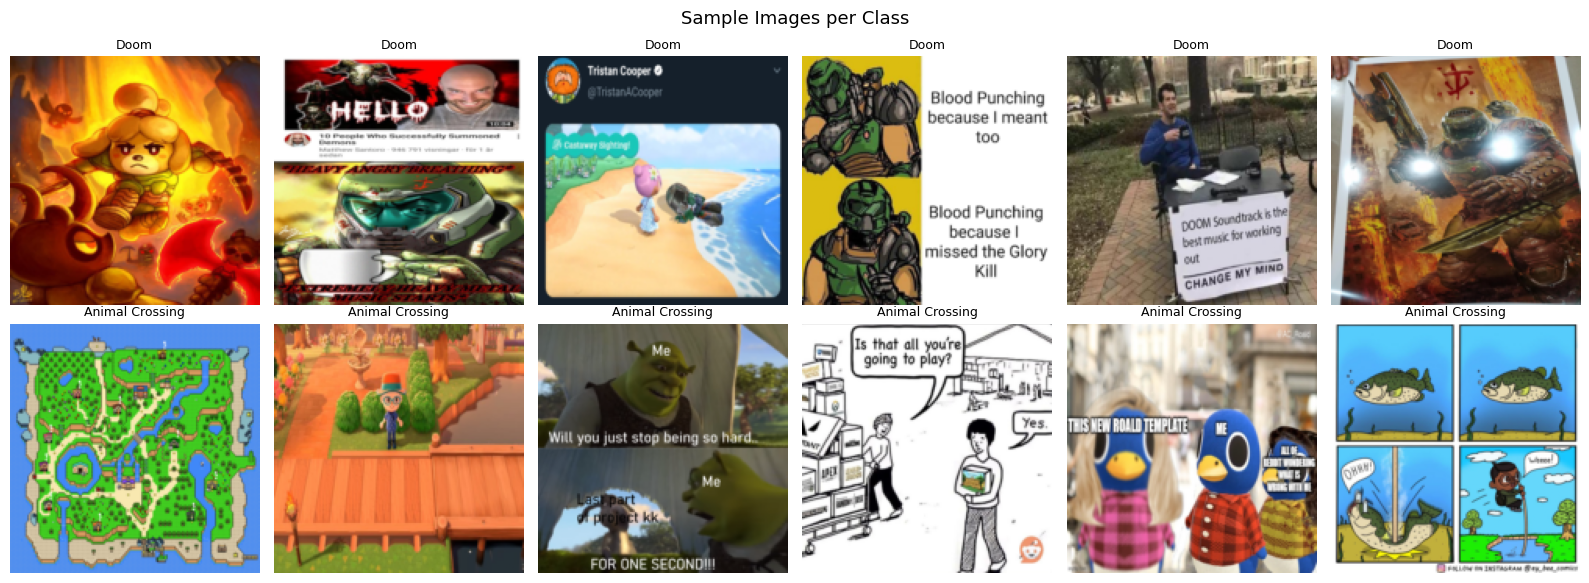

Label distribution →  Doom (0): 707   Animal Crossing (1): 678


In [6]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for cls, cls_name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    idx = np.where(y_all == cls)[0]
    row = 0 if cls == 0 else 1
    for col in range(6):
        axes[row, col].imshow(X_all[idx[col]])
        axes[row, col].set_title(cls_name, fontsize=9)
        axes[row, col].axis('off')
plt.suptitle('Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.show()

print('Label distribution →  Doom (0):', (y_all == 0).sum(),
      '  Animal Crossing (1):', (y_all == 1).sum())


## 5. Train / Validation Split

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_all
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}')


Train: (1177, 160, 160, 3)  Val: (208, 160, 160, 3)


## 6. Data Augmentation Pipeline

Richer augmentation than v1: adds **hue/saturation jitter** and **random rotation** to improve generalisation. Applied **only during training**.

In [9]:
@tf.function
def augment(image, label):
    """Augment a single (H, W, C) image tensor during training."""
    # Flips
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    # Colour jitter (more aggressive than v1)
    image = tf.image.random_brightness(image,  max_delta=0.2)
    image = tf.image.random_contrast(image,    lower=0.75, upper=1.25)
    image = tf.image.random_saturation(image,  lower=0.6,  upper=1.4)
    image = tf.image.random_hue(image,          max_delta=0.05)
    # Random crop (pad 12 % then crop back)
    pad = int(IMG_HEIGHT * 0.12)
    image = tf.image.pad_to_bounding_box(image, pad, pad,
                                          IMG_HEIGHT + 2*pad,
                                          IMG_WIDTH  + 2*pad)
    image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    # Random rotation ±15°  (using keras preprocessing layer via tf ops)
    angle = tf.random.uniform([], -0.26, 0.26)  # radians
    image = _rotate_image(image, angle)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def _rotate_image(image, angle):
    """Rotate image by `angle` radians using affine transform."""
    import tensorflow as tf
    cos_a = tf.math.cos(angle)
    sin_a = tf.math.sin(angle)
    h = tf.cast(IMG_HEIGHT, tf.float32)
    w = tf.cast(IMG_WIDTH,  tf.float32)
    cx, cy = w / 2.0, h / 2.0
    # Build 8-element transform for tfa-free rotation via raw ops
    transform = [cos_a, -sin_a, cx - cx*cos_a + cy*sin_a,
                 sin_a,  cos_a, cy - cx*sin_a - cy*cos_a,
                 0.0, 0.0]
    transform = tf.stack(transform)[tf.newaxis]  # (1, 8)
    image = tf.raw_ops.ImageProjectiveTransformV3(
    images=image[tf.newaxis],
    transforms=transform,
    output_shape=[IMG_HEIGHT, IMG_WIDTH],
    interpolation='BILINEAR',
    fill_mode='REFLECT',
    fill_value=0.0
    )[0]
    return image


AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset
            .from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset
            .from_tensor_slices(X_test)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print('Datasets ready.')


Datasets ready.


## 7. Deep Neural Network Architecture

**CNN with residual skip connections**, trained from scratch. Key upgrades over v1:
- Residual connections in each block (helps gradient flow in deeper net)
- Squeeze-and-Excitation channel attention (improves feature selection)
- SpatialDropout2D (better spatial regularisation than standard Dropout)
- 5 blocks instead of 4 (more capacity at larger image size)

All design choices remain compliant with the *no pre-trained weights* rule.

In [10]:
def se_block(x, ratio=8):
    """Squeeze-and-Excitation channel attention block."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)           # squeeze
    se = layers.Dense(max(filters // ratio, 4),
                      activation='relu',
                      kernel_initializer='he_normal')(se)  # excite down
    se = layers.Dense(filters,
                      activation='sigmoid',
                      kernel_initializer='glorot_uniform')(se)  # excite up
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])                 # scale channels


def conv_bn_relu(x, filters, kernel_size=3, strides=1):
    """Conv → BN → ReLU (no bias since BN absorbs it)."""
    x = layers.Conv2D(
            filters, kernel_size,
            strides=strides,
            padding='same',
            use_bias=False,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(L2_LAMBDA)
        )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def residual_block(x, filters, downsample=False):
    """Residual block: [Conv→BN→ReLU→Conv→BN] + skip + ReLU + SE."""
    strides = 2 if downsample else 1
    shortcut = x

    out = conv_bn_relu(x, filters, strides=strides)
    out = layers.Conv2D(
            filters, 3,
            padding='same',
            use_bias=False,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(L2_LAMBDA)
        )(out)
    out = layers.BatchNormalization()(out)

    # Align shortcut dimensions when filter count or spatial size changes
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, 1,
            strides=strides,
            padding='same',
            use_bias=False,
            kernel_initializer='he_normal'
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add()([out, shortcut])
    out = layers.Activation('relu')(out)
    out = se_block(out)                         # channel attention
    return out


def build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                num_classes=2):
    inputs = keras.Input(shape=input_shape)

    # ── Stem: initial conv ───────────────────────────────────
    x = conv_bn_relu(inputs, 32, kernel_size=7)   # 160→160
    x = layers.MaxPooling2D(2)(x)                 # 160→80
    x = layers.SpatialDropout2D(0.1)(x)

    # ── Block 1: 64 filters ──────────────────────────────────
    x = residual_block(x, 64, downsample=False)
    x = residual_block(x, 64, downsample=False)
    x = layers.MaxPooling2D(2)(x)                 # 80→40
    x = layers.SpatialDropout2D(0.15)(x)

    # ── Block 2: 128 filters ─────────────────────────────────
    x = residual_block(x, 128, downsample=False)
    x = residual_block(x, 128, downsample=False)
    x = layers.MaxPooling2D(2)(x)                 # 40→20
    x = layers.SpatialDropout2D(0.2)(x)

    # ── Block 3: 256 filters ─────────────────────────────────
    x = residual_block(x, 256, downsample=False)
    x = residual_block(x, 256, downsample=False)
    x = layers.MaxPooling2D(2)(x)                 # 20→10
    x = layers.SpatialDropout2D(0.2)(x)

    # ── Block 4: 512 filters ─────────────────────────────────
    x = residual_block(x, 512, downsample=False)
    x = layers.GlobalAveragePooling2D()(x)

    # ── Classifier head ──────────────────────────────────────
    x = layers.Dense(
            512,
            activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(L2_LAMBDA)
        )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    x = layers.Dense(
            256,
            activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(L2_LAMBDA)
        )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='ResidualCNN_Classifier')


model = build_model()
model.summary()


Model: "ResidualCNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │      4,704 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 160, 160,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 80, 80,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 80, 80,    │          0 │ max_pooling2d[0]… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 80, 80,    │     18,432 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 80, 80,    │      2,048 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 80,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p

 Total params: 6,950,162 (26.51 MB)

 Trainable params: 6,941,010 (26.48 MB)

 Non-trainable params: 9,152 (35.75 KB)

## 8. Compile — Warmup + Cosine Decay LR + Adam

**LR warmup** prevents early high-LR instability. After warmup the schedule follows cosine decay to a near-zero minimum.

In [11]:
class WarmUpCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup then cosine decay."""
    def __init__(self, init_lr, warmup_steps, total_steps, min_lr=1e-6):
        super().__init__()
        self.init_lr     = init_lr
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.min_lr       = min_lr

    def __call__(self, step):
        step   = tf.cast(step, tf.float32)
        warmup = tf.cast(self.warmup_steps, tf.float32)
        total  = tf.cast(self.total_steps,  tf.float32)

        # Linear warmup
        warmup_lr = self.init_lr * (step / warmup)
        # Cosine decay
        progress  = (step - warmup) / tf.maximum(total - warmup, 1.0)
        cosine_lr = self.min_lr + 0.5 * (self.init_lr - self.min_lr) * (
                        1.0 + tf.math.cos(np.pi * progress))
        return tf.where(step < warmup, warmup_lr, cosine_lr)

    def get_config(self):
        return {'init_lr': self.init_lr, 'warmup_steps': self.warmup_steps,
                'total_steps': self.total_steps, 'min_lr': self.min_lr}


steps_per_epoch  = len(X_train) // BATCH_SIZE
warmup_steps     = LR_WARMUP * steps_per_epoch
total_steps      = EPOCHS     * steps_per_epoch

lr_schedule = WarmUpCosineDecay(LR_INIT, warmup_steps, total_steps)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

# ── Class weights: balance the loss toward the minority class ─
# Balanced accuracy penalises per-class recall equally — class weights help.
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}
print('Class weights:', class_weights)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print('Model compiled.')


Class weights: {0: np.float64(0.9792013311148087), 1: np.float64(1.0217013888888888)}
Model compiled.


## 9. Callbacks

In [14]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]


## 10. Training

In [15]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5541 - loss: 1.2865
Epoch 1: val_accuracy improved from None to 0.63942, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5743 - loss: 1.2278 - val_accuracy: 0.6394 - val_loss: 1.0584
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5943 - loss: 1.1583
Epoch 2: val_accuracy improved from 0.63942 to 0.66346, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.5684 - loss: 1.2000 - val_accuracy: 0.6635 - val_loss: 0.9848
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5521 - loss: 1.1996
Epoch 3: val_accuracy improved from 0.66346 to 0.66827, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.5684 - loss: 1.1943 - val_accuracy: 0.6683 - val_loss: 0.9790
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5888 - loss: 1.1656
Epoch 4: val_accuracy improved from 0.66827 to 0.67788, sa

## 11. Training Curves

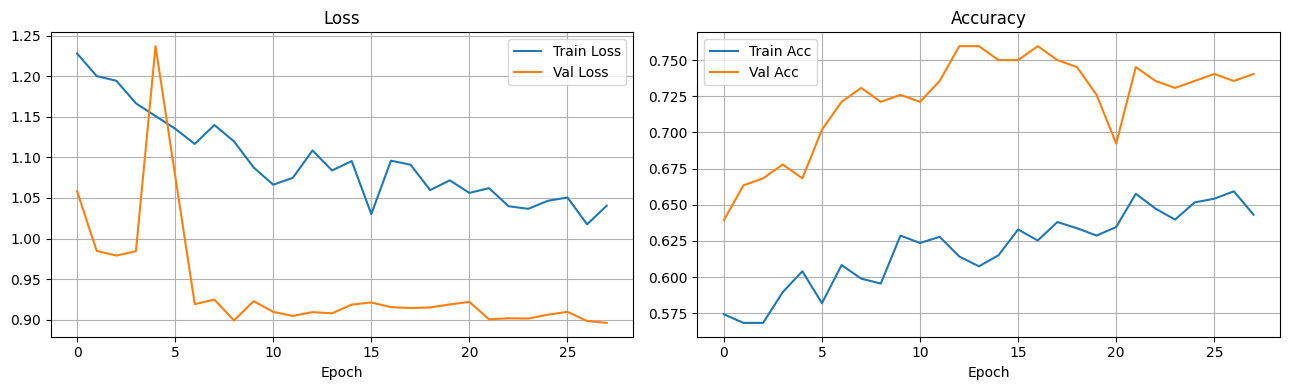

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()


## 12. Validation Evaluation (Balanced Accuracy)

In [17]:
val_probs = model.predict(val_ds, verbose=0)   # (N, 2)
val_preds = np.argmax(val_probs, axis=1)

bal_acc = balanced_accuracy_score(y_val, val_preds)
print(f'Validation Balanced Accuracy: {bal_acc:.4f}')

for cls, name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    mask    = y_val == cls
    cls_acc = (val_preds[mask] == y_val[mask]).mean()
    print(f'  Class {cls} ({name:15s}): {cls_acc:.4f}')


Validation Balanced Accuracy: 0.7588
  Class 0 (Doom           ): 0.8019
  Class 1 (Animal Crossing): 0.7157


## 13. Test Set Prediction with Test-Time Augmentation (TTA)

TTA averages predictions over **multiple augmented versions** of each test image. This consistently improves generalisation and calibration.

In [18]:
@tf.function
def augment_single(image):
    """Single-image augmentation for TTA (no label)."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image,  max_delta=0.1)
    image = tf.image.random_contrast(image,    lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image,  lower=0.8, upper=1.2)
    pad = int(IMG_HEIGHT * 0.08)
    image = tf.image.pad_to_bounding_box(image, pad, pad,
                                          IMG_HEIGHT + 2*pad,
                                          IMG_WIDTH  + 2*pad)
    image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    return tf.clip_by_value(image, 0.0, 1.0)


def predict_tta(model, X, tta_steps=TTA_STEPS, batch_size=BATCH_SIZE):
    """Return averaged softmax probabilities over TTA_STEPS augmented passes."""
    prob_sum = np.zeros((len(X), 2), dtype=np.float32)

    for step in range(tta_steps):
        aug_ds = (tf.data.Dataset
                  .from_tensor_slices(X)
                  .map(lambda img: augment_single(img),
                       num_parallel_calls=tf.data.AUTOTUNE)
                  .batch(batch_size)
                  .prefetch(tf.data.AUTOTUNE))
        prob_sum += model.predict(aug_ds, verbose=0)

    # Also include a clean (no-aug) pass for stability
    clean_ds = (tf.data.Dataset
                .from_tensor_slices(X)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))
    prob_sum += model.predict(clean_ds, verbose=0)

    return prob_sum / (tta_steps + 1)


print(f'Running TTA with {TTA_STEPS} augmented passes + 1 clean pass …')
test_probs = predict_tta(model, X_test)
test_preds = np.argmax(test_probs, axis=1)

print('Test predictions shape:', test_preds.shape)
print('Predicted label distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Label {u}: {c}')


Running TTA with 10 augmented passes + 1 clean pass …
Test predictions shape: (1386,)
Predicted label distribution:
  Label 0: 736
  Label 1: 650


## 14. TTA Validation Balanced Accuracy

In [19]:
print('Running TTA on validation set …')
val_probs_tta = predict_tta(model, X_val, tta_steps=TTA_STEPS)
val_preds_tta = np.argmax(val_probs_tta, axis=1)

bal_acc_tta = balanced_accuracy_score(y_val, val_preds_tta)
print(f'Validation Balanced Accuracy (TTA): {bal_acc_tta:.4f}')

for cls, name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    mask    = y_val == cls
    cls_acc = (val_preds_tta[mask] == y_val[mask]).mean()
    print(f'  Class {cls} ({name:15s}): {cls_acc:.4f}')


Running TTA on validation set …
Validation Balanced Accuracy (TTA): 0.7490
  Class 0 (Doom           ): 0.8019
  Class 1 (Animal Crossing): 0.6961


# Generating Final Submission

In [20]:
test_ids = TEST_LABEL.index.tolist()

submission = pd.DataFrame({
    'id':    test_ids,
    'label': test_preds
})
submission = submission.set_index('id')

submission.to_csv('submission4.csv')
print('submission4.csv saved!')
print(submission.head(10))


submission4.csv saved!
      label
id         
2078      1
2079      1
2080      0
2081      0
2082      0
2083      1
2084      0
2085      0
2086      1
2087      0


## ✅ Verify Submission Format

In [21]:
sub_check = pd.read_csv('submission.csv', index_col='id')
print('Submission shape:', sub_check.shape)
print('Unique labels:', sorted(sub_check['label'].unique()))
assert set(sub_check['label'].unique()).issubset({0, 1}),     'ERROR: labels must be 0 or 1!'
assert len(sub_check) == len(TEST_LABEL),     f'ERROR: expected {len(TEST_LABEL)} rows, got {len(sub_check)}'
print('✅ Submission looks correct – ready to upload to Kaggle!')


Submission shape: (1386, 1)
Unique labels: [np.int64(-1)]


AssertionError: ERROR: labels must be 0 or 1!